Test Accuracy: 0.5558
Theta shape: (10, 784)
Variance shape: (10, 784)


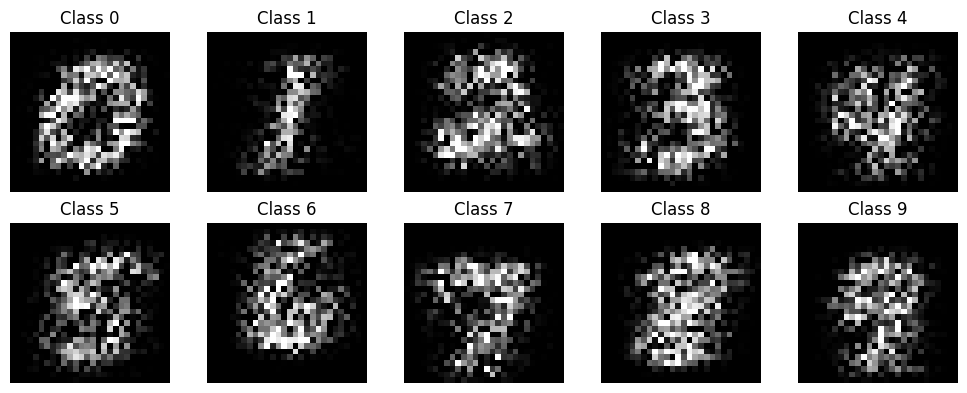

In [3]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score


# 1. Load MNIST data from TensorFlow

(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalize pixel values to [0, 1]
X_train = X_train / 255.0
X_test = X_test / 255.0


# 2. Flatten 28x28 images to 784-dimensional vectors

X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

# 3. Train Gaussian Naive Bayes (10-class classifier)

gnb = GaussianNB()
gnb.fit(X_train_flat, y_train)

# Optional: evaluate classifier
y_pred = gnb.predict(X_test_flat)
print("Test Accuracy:", accuracy_score(y_test, y_pred))

# 4. Access learned distributions

# gnb.theta_ -> mean of each pixel per class
# gnb.var_   -> variance of each pixel per class
print("Theta shape:", gnb.theta_.shape)  # (10, 784)
print("Variance shape:", gnb.var_.shape) # (10, 784)

# 5. Generate new data using learned Gaussians

def generate_digit(class_label, model):
    mean = model.theta_[class_label]
    var = model.var_[class_label]

    # Sample each pixel independently
    sample = np.random.normal(mean, np.sqrt(var))

    # Clip to valid range
    sample = np.clip(sample, 0, 1)

    return sample.reshape(28, 28)

# 6. Visualize generated digits

fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for digit, ax in enumerate(axes.flat):
    generated_image = generate_digit(digit, gnb)
    ax.imshow(generated_image, cmap="gray")
    ax.set_title(f"Class {digit}")
    ax.axis("off")

plt.tight_layout()
plt.show()
